# News Articles Grouping Research

### Problem

The main problem we aim to address in this research is the challenge of grouping news articles into meaningful real-world events. The goal is not to cluster them solely based on semantic similarity or broad topics, but to organize them according to specific real-world events, where all articles report on the same occurrence, potentially from different perspectives, narratives, or angles.

Most existing approaches are either not publicly available, require human-in-the-loop intervention, or focus on semantic/topic similarity rather than true event-level grouping.

## Introduction

In this notebook, we perform an Exploratory Data Analysis (EDA) of the first dataset used in this research: **WCEP (Wikipedia Current Events Portal)**. This dataset contains a total of 10,200 unique events, each associated with a collection of related news articles describing the same real-world occurrence. In total, the dataset includes 649,575 news articles from over 6,681 news outlets.

The objective of this analysis is to gain insights that help us better understand the structure, distribution, and characteristics of the data. These insights will guide the design of a more effective solution to the event-grouping problem. Finally, we will prepare and preprocess the dataset for integration into our pipeline.

**Dataset reference:**  
[*A Large-Scale Multi-Document Summarization Dataset from the Wikipedia Current Events Portal*](https://github.com/complementizer/wcep-mds-dataset)


### Import Depencies

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt

from urllib.parse import urlparse

In [2]:
LOAD_DATASET_PATH = "/content/articles_events_full.jsonl"
SAVE_DATASET_PATH = "/content/output.csv"

## 1. Data Loading

In this section, we load the dataset using a streaming approach to avoid memory overload. The original dataset is structured as a `.jsonl` file, where each line represents a single event. Each event contains metadata and a collection of associated news articles.

For the purposes of this analysis and the downstream pipeline, we extract only the relevant fields needed for exploration and processing.

### Process Full Dataset

In [ ]:
data_list = []

with open("/content/articles_events_full.jsonl", "r") as f:
    for line in f:
        record = json.loads(line)
        event_id = record["id"]

        for article in record["articles"]:
            data_list.append({
                "id": article["id"],
                "title": article["title"],
                "content": article["text"],
                "url": article["url"],
                "event_id": event_id,
            })

df = pd.DataFrame(data_list)
print(f"Generated articles dataframe with {len(data_list)} examples.")

Generated articles dataframe with 649575 examples.


### Process 2.5K Events Dataset

In [ ]:
import random

with open(LOAD_DATASET_PATH, "r") as f:
    all_event_ids = [json.loads(line)["id"] for line in f]

random.seed(42)
sampled_event_ids = set(random.sample(all_event_ids, 2500))

data_list = []

with open(LOAD_DATASET_PATH, "r") as f:
    for line in f:
        record = json.loads(line)
        event_id = record["id"]

        if event_id not in sampled_event_ids:
            continue

        for article in record["articles"]:
            data_list.append({
                "id": article["id"],
                "title": article["title"],
                "content": article["text"],
                "url": article["url"],
                "event_id": event_id,
            })

df = pd.DataFrame(data_list)
print(f"Sampled {len(sampled_event_ids)} events → {len(data_list)} articles")

In [5]:
# Shuffling the dataset to about possible patterns
df = df.sample(frac=1, random_state=42)
df = df.reset_index(drop=True)

## 2. Data Analysis

After loading the data and constructing our DataFrame, we proceed with an exploratory analysis to extract insights that are relevant to our research objectives.

The analyses performed in this section include:

- **Average number of articles per event**  
- **Average number of unique news outlets per event**  
- **Average length of article titles and content**  
- **Overall distribution of news outlets**, to assess whether events are covered by a diverse set of media sources or are dominated by a small number of outlets

### Average Number of Articles per Event

In [ ]:
grouped_articles_by_event = df.groupby("event_id")["id"].count()

average_articles_per_event = grouped_articles_by_event.mean()
max_articles_count = grouped_articles_by_event.max()
min_articles_count = grouped_articles_by_event.min()

print(f"Average number of articles per event: {average_articles_per_event:.2f}")
print(f"Max. number of articles in an event: {max_articles_count}")
print(f"Min. number of articles in an event: {min_articles_count}")

Average number of articles per event: 63.68
Max. number of articles in an event: 100
Min. number of articles in an event: 1


> **Result:** On average, each event contains **63.68** articles. The event with the highest number of associated articles contains **100**, while the event with the lowest contains only **1** article.

### Average Number of Unique News Outlets per Event

In [ ]:
df["source"] = [urlparse(url).hostname for url in df["url"]]
df["source"] = (
    df["source"]
    .astype(str)
    .str.strip()
    .str.lower()
)

df = df.drop(labels=["url"], axis=1)

In [ ]:
grouped_sources_by_event = df.groupby("event_id")["source"].nunique()

average_sources_per_event = grouped_sources_by_event.mean()
max_sources_count = grouped_sources_by_event.max()
min_sources_count = grouped_sources_by_event.min()

print(f"Average number of sources per event: {average_sources_per_event:.2f}")
print(f"Max. number of sources in an event: {max_sources_count}")
print(f"Min. number of sources in an event: {min_sources_count}")

Average number of sources per event: 41.81
Max. number of sources in an event: 98
Min. number of sources in an event: 1


> **Result:** On average, each event contains **41.81** sources. The event with the highest number of associated sources contains **98**, while the event with the lowest contains only **1** source.

### Average Length of Article Title & Content

In [ ]:
df["title_word_count"] = df["title"].astype(str).str.count(r'\S+')
df["content_word_count"] = df["content"].astype(str).str.count(r'\S+')

print(f"Description (Title):\n{df["title_word_count"].describe()}\n")
print(f"Description (Content):\n{df["content_word_count"].describe()}")

Description (Title):
count    649575.000000
mean          9.965427
std           2.919622
min           0.000000
25%           8.000000
50%          10.000000
75%          11.000000
max         523.000000
Name: title_word_count, dtype: float64

Description (Content):
count    649575.000000
mean        420.611060
std         389.990278
min           0.000000
25%         166.000000
50%         345.000000
75%         572.000000
max       42871.000000
Name: content_word_count, dtype: float64


In [ ]:
print(f"Articles count with title having more than 30 words: {df[df["title_word_count"] > 30]["id"].count()}")
print(f"Articles count with title having more than 50 words: {df[df["title_word_count"] > 50]["id"].count()}")
print(f"Articles count with title having more than 100 words: {df[df["title_word_count"] > 100]["id"].count()}")

Articles count with title having more than 30 words: 179
Articles count with title having more than 50 words: 5
Articles count with title having more than 100 words: 4


In [ ]:
print(f"Articles count with content having more than 1,000 words: {df[df["content_word_count"] > 1_000]["id"].count()}")
print(f"Articles count with content having more than 5,000 words: {df[df["content_word_count"] > 5_000]["id"].count()}")
print(f"Articles count with content having more than 10,000 words: {df[df["content_word_count"] > 10_000]["id"].count()}")

Articles count with content having more than 1,000 words: 32696
Articles count with content having more than 5,000 words: 296
Articles count with content having more than 10,000 words: 43


After conducting a more detailed analysis of article title and content lengths, we identified the presence of several outliers.

- **Title length:** Most articles have titles shorter than 30 words. Only 188 articles exceed this length, including one extreme case with over 500 words.

- **Content length:** The majority of articles contain fewer than 5,000 words, with only 339 articles exceeding this threshold.

These values will be used as filtering thresholds to remove outliers during preprocessing.

In [ ]:
print(f"Dataframe length (Before filtering): {df.shape[0]} articles.")
df = df[(df["title_word_count"] <= 30) &
        (df["title_word_count"] > 0) &
        (df["content_word_count"] <= 5_000) &
        (df["content_word_count"] > 0)]
print(f"Dataframe length (After filtering): {df.shape[0]} articles.")

df = df.drop(labels=["title_word_count", "content_word_count"], axis=1)

Dataframe length (Before filtering): 649575 articles.
Dataframe length (After filtering): 647442 articles.


In [ ]:
df["title_word_count"] = df["title"].astype(str).str.count(r'\S+')
df["content_word_count"] = df["content"].astype(str).str.count(r'\S+')

print(f"Description (Title):\n{df["title_word_count"].describe()}\n")
print(f"Description (Content):\n{df["content_word_count"].describe()}")

df = df.drop(labels=["title_word_count", "content_word_count"] , axis=1)

Description (Title):
count    647442.000000
mean          9.962696
std           2.788475
min           1.000000
25%           8.000000
50%          10.000000
75%          11.000000
max          30.000000
Name: title_word_count, dtype: float64

Description (Content):
count    647442.000000
mean        417.861484
std         337.836440
min           3.000000
25%         168.000000
50%         346.000000
75%         572.000000
max        4968.000000
Name: content_word_count, dtype: float64


# Overall Distribution of News Outlets

In [ ]:
unique_news_outlets = df["source"].nunique()
print(f"Unique amount of news outlets: {unique_news_outlets}")

Unique amount of news outlets: 6579


In [ ]:
print(f"Sources w/amount of articles (Descending): \n{df.groupby("source")["id"].count().sort_values(ascending=False)[:10]}")

Sources w/amount of articles (Descending): 
source
www.dailymail.co.uk        31659
none                       30803
www.reuters.com            23056
www.channelnewsasia.com    10691
www.cnn.com                 8691
in.reuters.com              8327
www.seattletimes.com        7683
www.express.co.uk           6204
www.theguardian.com         5369
www.foxnews.com             5246
Name: id, dtype: int64


In [ ]:
print(f"Sources w/amount of articles (Ascending): \n{df.groupby("source")["id"].count().sort_values(ascending=True)[:10]}")

Sources w/amount of articles (Ascending): 
source
321steve.newsvine.com         1
303cycling.com                1
21stcenturywire.com           1
1unlikelylady.newsvine.com    1
1hiram.newsvine.com           1
12160.info                    1
1069thelight.org              1
www.laht.com                  1
www.lagniappemobile.com       1
www.kzkx.com                  1
Name: id, dtype: int64


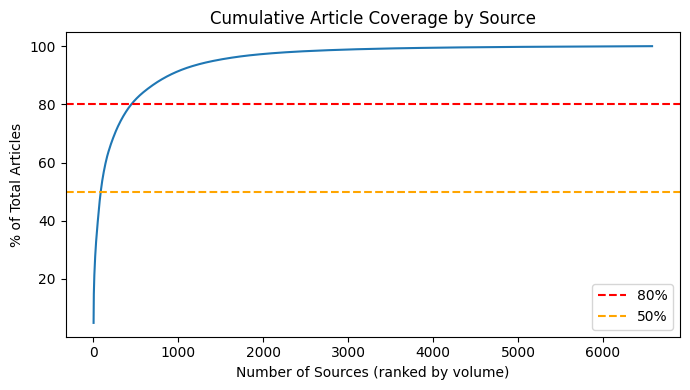

In [ ]:
source_counts = df["source"].value_counts()
cumulative = source_counts.cumsum() / source_counts.sum() * 100

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cumulative) + 1), cumulative.values)
plt.axhline(80, color="red", linestyle="--", label="80%")
plt.axhline(50, color="orange", linestyle="--", label="50%")
plt.title("Cumulative Article Coverage by Source")
plt.xlabel("Number of Sources (ranked by volume)")
plt.ylabel("% of Total Articles")
plt.legend()
plt.tight_layout()
plt.show()

The distribution indicates a strong concentration of articles among a relatively small number of high-volume news outlets.

| Threshold            | What the Curve Shows                                                                 |
|----------------------|---------------------------------------------------------------------------------------|
| 50% of articles      | ~100 sources
| 80% of articles      | ~400–500 sources                                     |
| Remaining 20%        | ~6,200 sources                      |


<br/>

Although this imbalance could bias a model toward the writing style and editorial patterns of the most frequent sources, our task focuses on clustering rather than supervised classification. Therefore, this issue may have a limited impact. Nevertheless, we will further analyze whether retaining all sources is appropriate or if additional filtering is necessary.

In [ ]:
print(f"Sources with only 1 article: {(source_counts == 1).sum()}")

Sources with only 1 article: 1777


In [ ]:
for threshold in [1, 5, 10, 25, 50, 100]:
    kept = df[df["source"].isin(source_counts[source_counts >= threshold].index)]
    print(f"min={threshold:>4} | sources: {(source_counts >= threshold).sum():>5} | articles: {len(kept):>7} ({len(kept)/len(df)*100:.1f}%)")

min=   1 | sources:  6579 | articles:  647442 (100.0%)
min=   5 | sources:  3299 | articles:  641580 (99.1%)
min=  10 | sources:  2457 | articles:  635947 (98.2%)
min=  25 | sources:  1733 | articles:  624657 (96.5%)
min=  50 | sources:  1256 | articles:  607972 (93.9%)
min= 100 | sources:   867 | articles:  580250 (89.6%)


The source distribution reveals a clear long-tail pattern: approximately 80% of the articles are concentrated within the top ~400-500 news outlets, while the remaining ~6,000 sources contribute only 20% of the total volume. Notably, 1,836 sources appear only once in the dataset.

Although this imbalance could suggest potential noise or instability introduced by extremely low-frequency publishers, low frequency does not necessarily imply low quality. These smaller outlets may provide niche, local, or alternative coverage of events that are underrepresented in mainstream media. Since the objective of this research is event-level clustering, maintaining diversity in reporting styles and perspectives can actually strengthen the robustness of the clustering process.

Removing low-frequency sources could slightly reduce stylistic variance and long-tail sparsity, but it would also introduce a bias toward mainstream media and weaken the representational breadth of the dataset. Given that one of the goals of this research is to preserve a broad and inclusive view of media coverage, we choose to retain all sources at this stage.

Rather than applying heuristic filtering, we will evaluate empirically whether low-frequency publishers negatively impact clustering quality. If measurable degradation is observed (e.g., excessive singleton clusters or instability), we may introduce controlled filtering as part of a comparative experiment. For now, maintaining the full distribution ensures maximal coverage and preserves the federal nature of the dataset.

# Conclusion

After performing EDA on the events dataset, we identified several data quality issues and distributional characteristics that informed our preprocessing decisions:

- Some article titles contained **0 words**, while a very small number were extreme outliers (one exceeding 500 words). These cases were considered anomalous and removed.

- Similarly, some article contents contained **0 words**, and a small number were extreme outliers (one exceeding 40,000 words). These were also removed as part of the cleaning process.

With these two filtering steps, the dataset was reduced by **2,133 articles**, improving overall consistency while preserving the vast majority of the data.

Additionally:

- We observed a strong long-tail distribution in source frequency. Approximately **80% of the articles are concentrated within the top ~400–500 news outlets**, while the remaining ~6,000 sources contribute only 20% of the total volume.

Rather than removing low-frequency sources, which would bias the dataset toward mainstream media, we choose to retain them in order to preserve diversity and maintain a broad representation of media coverage. However, this characteristic will be explicitly considered during the experimentation phase. We plan to compare clustering results using:

1. The full dataset (all sources and articles), and  
2. A filtered version excluding very low-frequency sources (e.g., keeping only sources with at least 2–3 articles), which would remove approximately ~1.8k sources and reduce the total article count accordingly.

This comparative evaluation will allow us to determine empirically whether long-tail sparsity affects clustering performance.

### Saving Final Dataset

The EDA was performed on the full dataset of **10,200 unique events**, corresponding to **649,575 news articles**. However, running the complete pipeline on this scale proved computationally prohibitive, with individual steps taking upwards of 7 hours, making iteration and experimentation impractical.

To address this, we randomly sampled **2,500 events (random_state=42)**, reducing the dataset to approximately **200k articles**. This brings a ~4x reduction in computation time, enabling faster iteration between experiments while preserving the distributional properties observed during EDA.

We believe this sample is sufficient to validate the pipeline and produce meaningful results, as the core research questions relate to the structure and quality of the clustering rather than exhaustive coverage of all events.

> *Note: The full 10,200-event dataset remains available for future work, once the pipeline has been validated at this scale.*

We do a final check to see if there is any null value remaning and then save the dataset as a `.csv` file.

In [ ]:
print(df.isnull().value_counts())

In [ ]:
df = df.drop(labels=["source"], axis=1)

In [8]:
from google.colab import files

df.to_csv(path_or_buf=SAVE_DATASET_PATH, index=False)
print(f"Dataset saved successfully in {SAVE_DATASET_PATH}")

files.download(SAVE_DATASET_PATH)
print(f"Dataset downloaded successfully")

Dataset saved successfully in /content/output.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Dataset downloaded successfully
